# V1 Agent Lab - Component-by-Component Testing & Debugging

This notebook allows you to test and debug each component of the v1 agent workflow:
- **Setup & Imports**: Initialize environment and dependencies
- **Configuration**: LLM and Vector Store configuration
- **LLM Component**: Test LLM calls and prompting
- **RAG Component**: Test vector store retrieval
- **State Definition**: ConversationState structure
- **Node Functions**: Test individual nodes in isolation
- **Routing Functions**: Test routing logic
- **Graph Integration**: Build and test the full graph
- **End-to-End Testing**: Run full workflows

Modify cells as needed to test specific scenarios.

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json
import logging

# Add repo root for imports
repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

from dotenv import load_dotenv
load_dotenv()

# Setup logging
logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print(f"Repo root: {repo_root}")
print(f"Python path configured")

Repo root: /Users/jainer/Documents/routeThis
Python path configured


In [2]:
# Import core dependencies
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

print("Core dependencies imported successfully")

Core dependencies imported successfully


In [3]:
# Import project-specific modules
from shared.state.state_v1 import ConversationState
from shared.prompts.base_prompts import (
    SYSTEM_PROMPT
)
from shared.rag.retriever import build_retriever, retrieve

# Import node functions and routing logic from agents/v1/nodes.py
from agents.v1.nodes import (
    qualify, graceful_exit, guide_reboot,
    check_resolution, close_success, apologize_and_exit,
    route_after_qualify, route_after_guide, route_after_check,
)

# Import graph builder from agents/v1/graph.py
from agents.v1.graph import build_graph

print("Project modules imported successfully")
print(f"SYSTEM_PROMPT: {SYSTEM_PROMPT[:100]}...")
print("✓ Node functions imported from agents.v1.nodes")
print("✓ Routing functions imported from agents.v1.nodes")
print("✓ build_graph imported from agents.v1.graph")

Project modules imported successfully
SYSTEM_PROMPT: You are a friendly WiFi troubleshooting assistant for Linksys routers.
You help users diagnose and f...
✓ Node functions imported from agents.v1.nodes
✓ Routing functions imported from agents.v1.nodes
✓ build_graph imported from agents.v1.graph


## 2. Configuration - LLM & Vector Store

In [4]:
# LLM Configuration
LLM_MODEL = "gpt-4o-mini"
LLM_TEMPERATURE = 0.2

llm = ChatOpenAI(model=LLM_MODEL, temperature=LLM_TEMPERATURE)
print(f"LLM initialized: {LLM_MODEL} (temperature={LLM_TEMPERATURE})")

# Test LLM connectivity
# test_response = llm.invoke([SystemMessage(content="Say 'Ready'")])
# print(f"LLM test response: {test_response.content}")

LLM initialized: gpt-4o-mini (temperature=0.2)


In [5]:
# Vector Store Configuration
print("Building vector store retriever...")
vectorstore = build_retriever()
print(f"Vector store initialized: {type(vectorstore).__name__}")

# Test retrieval
test_results = retrieve(vectorstore, "router reboot steps power cord")
print(f"Retrieval test: {len(test_results)} documents found")
if test_results:
    print(f"First result preview: {test_results[0].page_content[:200]}...")

2026-03-31 16:55:38,459 - chromadb.config - DEBUG - Starting component System
2026-03-31 16:55:38,460 - chromadb.config - DEBUG - Starting component Posthog
2026-03-31 16:55:38,511 - openai._base_client - DEBUG - Request options: {'method': 'post', 'url': '/embeddings', 'files': None, 'idempotency_key': 'stainless-python-retry-106880e8-6ef6-4208-9d33-b32d278d1634', 'post_parser': <function Embeddings.create.<locals>.parser at 0x11aa52020>, 'content': None, 'json_data': {'input': [[10140, 35692, 7504, 2410, 23125]], 'model': 'text-embedding-3-small', 'encoding_format': 'base64'}}
2026-03-31 16:55:38,512 - openai._base_client - DEBUG - Sending HTTP Request: POST https://api.openai.com/v1/embeddings
2026-03-31 16:55:38,512 - httpcore.connection - DEBUG - connect_tcp.started host='api.openai.com' port=443 local_address=None timeout=None socket_options=None


Building vector store retriever...
Vector store initialized: Chroma


2026-03-31 16:55:38,557 - httpcore.connection - DEBUG - connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x11aa71e80>
2026-03-31 16:55:38,557 - httpcore.connection - DEBUG - start_tls.started ssl_context=<ssl.SSLContext object at 0x10c702960> server_hostname='api.openai.com' timeout=None
2026-03-31 16:55:38,586 - httpcore.connection - DEBUG - start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x11aab0190>
2026-03-31 16:55:38,587 - httpcore.http11 - DEBUG - send_request_headers.started request=<Request [b'POST']>
2026-03-31 16:55:38,587 - httpcore.http11 - DEBUG - send_request_headers.complete
2026-03-31 16:55:38,587 - httpcore.http11 - DEBUG - send_request_body.started request=<Request [b'POST']>
2026-03-31 16:55:38,587 - httpcore.http11 - DEBUG - send_request_body.complete
2026-03-31 16:55:38,588 - httpcore.http11 - DEBUG - receive_response_headers.started request=<Request [b'POST']>
2026-03-31 16:55:38,876 - httpcore.http11 - 

Retrieval test: 1 documents found
First result preview: After setup  The internet appears to be unavailable  If the internet has difficulty communicating with your router, the problem may appear as a “Cannot find [internet address]” message in your Web bro...


## 3. LLM Component - Call & JSON Parsing

In [6]:
# The _call_llm function is used internally by the nodes
# It handles LLM invocation and JSON parsing from markdown-fenced responses
# View implementation in: agents/v1/nodes.py:32-45

print("LLM component uses _call_llm() from agents.v1.nodes")
print("This function:")
print("  1. Combines system prompt + conversation history + task prompt")
print("  2. Invokes the LLM")
print("  3. Strips markdown code fences if present")
print("  4. Parses JSON from the response")
print("  5. Returns parsed dictionary with 'reply' and decision fields")

LLM component uses _call_llm() from agents.v1.nodes
This function:
  1. Combines system prompt + conversation history + task prompt
  2. Invokes the LLM
  3. Strips markdown code fences if present
  4. Parses JSON from the response
  5. Returns parsed dictionary with 'reply' and decision fields


In [7]:
# Test a node that uses _call_llm internally
test_messages = [
    HumanMessage(content="Hi, my WiFi keeps dropping every 10 minutes.")
]

test_state = ConversationState(messages=test_messages)

print("Testing qualify node (which uses _call_llm internally)...")
print(f"Input: {test_messages[0].content}")

result = qualify(test_state)
print(f"\nQualify result:")
print(f"  reboot_appropriate: {result.get('reboot_appropriate')}")
print(f"  exit_reason: {result.get('exit_reason')}")
print(f"  AI reply: {result['messages'][0].content[:100]}...")

2026-03-31 16:55:38,902 - urllib3.connectionpool - DEBUG - Starting new HTTPS connection (1): api.smith.langchain.com:443
2026-03-31 16:55:38,911 - openai._base_client - DEBUG - Request options: {'method': 'post', 'url': '/chat/completions', 'headers': {'X-Stainless-Helper-Method': 'chat.completions.parse', 'X-Stainless-Raw-Response': 'true'}, 'files': None, 'idempotency_key': 'stainless-python-retry-466a3393-f658-408b-b1bf-9ded3bb7c64c', 'post_parser': <function Completions.parse.<locals>.parser at 0x11aab7420>, 'content': None, 'json_data': {'messages': [{'content': 'You are a Senior WIFI Technitian Specialist interviewer agent. Your Goal is to determine whether a WIFI router reboot is needed. If not, exit the conversation gracefully.\n\n\n\n\nRules:\n- Don\'t ask similar questions. For example: "Are there any devices connected to the router that are showing a connection, or is everything completely offline?" and "Can you check if there are any other devices connected to the router, 

Testing qualify node (which uses _call_llm internally)...
Input: Hi, my WiFi keeps dropping every 10 minutes.


2026-03-31 16:55:39,149 - urllib3.connectionpool - DEBUG - https://api.smith.langchain.com:443 "POST /runs/multipart HTTP/1.1" 202 17
2026-03-31 16:55:40,065 - httpcore.http11 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Date', b'Tue, 31 Mar 2026 20:55:40 GMT'), (b'Content-Type', b'application/json'), (b'Transfer-Encoding', b'chunked'), (b'Connection', b'keep-alive'), (b'CF-Ray', b'9e524194ba2dd5f4-YYZ'), (b'CF-Cache-Status', b'DYNAMIC'), (b'Server', b'cloudflare'), (b'Strict-Transport-Security', b'max-age=31536000; includeSubDomains; preload'), (b'X-Content-Type-Options', b'nosniff'), (b'access-control-expose-headers', b'X-Request-ID'), (b'openai-organization', b'sharp-ai-owxedn'), (b'openai-processing-ms', b'968'), (b'openai-project', b'proj_3xffUHmUr6mhVrrBuYP3I9Hy'), (b'openai-version', b'2020-10-01'), (b'x-openai-proxy-wasm', b'v0.1'), (b'x-ratelimit-limit-requests', b'10000'), (b'x-ratelimit-limit-tokens', b'200000'), (b'x-ratelimit-remai


Qualify result:
  reboot_appropriate: None
  exit_reason: None
  AI reply: I understand how frustrating that can be. Can you tell me if the WiFi drops for all devices or just ...


2026-03-31 16:55:40,620 - langsmith.client - DEBUG - Sending compressed multipart request with context: trace=019d45ae-388f-7221-aa85-2cb58377a108,id=019d45ae-388f-7221-aa85-2cb58377a108; trace=019d45ae-3d33-7bc2-aef8-081ee65c24cf,id=019d45ae-3d33-7bc2-aef8-081ee65c24cf
2026-03-31 16:55:40,696 - urllib3.connectionpool - DEBUG - https://api.smith.langchain.com:443 "POST /runs/multipart HTTP/1.1" 202 17
2026-03-31 16:55:41,491 - langsmith.client - DEBUG - Sending compressed multipart request with context: trace=019d45ae-3d33-7bc2-aef8-081ee65c24cf,id=019d45ae-3d33-7bc2-aef8-081ee65c24cf
2026-03-31 16:55:41,562 - urllib3.connectionpool - DEBUG - https://api.smith.langchain.com:443 "POST /runs/multipart HTTP/1.1" 202 17


In [8]:
# Test another prompt through the node
print("Testing check_resolution node...")
test_messages_2 = [
    HumanMessage(content="My WiFi was dropping."),
    AIMessage(content="Let's try rebooting the router."),
    HumanMessage(content="OK, I rebooted it."),
    AIMessage(content="Did that fix the issue?"),
    HumanMessage(content="Yes, it's working perfectly now!"),
]

test_state_2 = ConversationState(messages=test_messages_2, current_step=4)

result = check_resolution(test_state_2)
print(f"\nCheck resolution result:")
print(f"  issue_resolved: {result.get('issue_resolved')}")
print(f"  AI reply: {result['messages'][0].content[:100]}...")

2026-03-31 16:55:40,085 - openai._base_client - DEBUG - Request options: {'method': 'post', 'url': '/chat/completions', 'headers': {'X-Stainless-Helper-Method': 'chat.completions.parse', 'X-Stainless-Raw-Response': 'true'}, 'files': None, 'idempotency_key': 'stainless-python-retry-6e5ff3f0-4fb7-4e9a-967c-2787748ebc27', 'post_parser': <function Completions.parse.<locals>.parser at 0x11aab79c0>, 'content': None, 'json_data': {'messages': [{'content': 'The user has completed all reboot steps.\nAsk them to test their internet connection and report back.\n\nRespond with JSON:\n{{\n    "reply": "your message to the user",\n    "resolved": true | false | null\n}}\n\nSet resolved to null if the user response is not well defined, vague anwser (neighter confirming resolution nor issue persistance). In this case ask a more clarifying question to determine whether the issue is gone or persist.\n\nSet resolve to true if the user confirmed the issue is fixed.\n\nSet resolve to false if the issue per

Testing check_resolution node...


2026-03-31 16:55:40,955 - httpcore.http11 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Date', b'Tue, 31 Mar 2026 20:55:40 GMT'), (b'Content-Type', b'application/json'), (b'Transfer-Encoding', b'chunked'), (b'Connection', b'keep-alive'), (b'CF-Ray', b'9e52419bbcebd5f4-YYZ'), (b'CF-Cache-Status', b'DYNAMIC'), (b'Server', b'cloudflare'), (b'Strict-Transport-Security', b'max-age=31536000; includeSubDomains; preload'), (b'X-Content-Type-Options', b'nosniff'), (b'access-control-expose-headers', b'X-Request-ID'), (b'openai-organization', b'sharp-ai-owxedn'), (b'openai-processing-ms', b'743'), (b'openai-project', b'proj_3xffUHmUr6mhVrrBuYP3I9Hy'), (b'openai-version', b'2020-10-01'), (b'x-openai-proxy-wasm', b'v0.1'), (b'x-ratelimit-limit-requests', b'10000'), (b'x-ratelimit-limit-tokens', b'200000'), (b'x-ratelimit-remaining-requests', b'9998'), (b'x-ratelimit-remaining-tokens', b'199826'), (b'x-ratelimit-reset-requests', b'16.163s'), (b'x-ratelimit-re


Check resolution result:
  issue_resolved: True
  AI reply: Great to hear that your internet is working perfectly now!...


## 8. Graph Integration - Build & Compile

In [9]:
# Test route_after_check
print("=== Testing route_after_check ===")

test_cases = [
    (ConversationState(issue_resolved=None), "check_resolution (issue_resolved=None)"),
    (ConversationState(issue_resolved=True), "close_success (issue_resolved=True)"),
    (ConversationState(issue_resolved=False), "apologize_and_exit (issue_resolved=False)"),
]

for state, desc in test_cases:
    route = route_after_check(state)
    print(f"{desc} → {route}")

=== Testing route_after_check ===
check_resolution (issue_resolved=None) → __end__
close_success (issue_resolved=True) → close_success
apologize_and_exit (issue_resolved=False) → apologize_and_exit


In [10]:
# build_graph function is imported from agents.v1.graph
# View implementation in: agents/v1/graph.py:15-58
#
# It creates a StateGraph with all nodes and edges configured:
# - 7 nodes (qualify, guide_reboot, check_resolution, etc.)
# - Conditional edges for routing logic
# - Terminal nodes (graceful_exit, close_success, apologize_and_exit)

print("build_graph imported from agents.v1.graph")
print("Any changes to graph.py will be reflected immediately")

build_graph imported from agents.v1.graph
Any changes to graph.py will be reflected immediately


In [11]:
# Build and compile graph
print("Building and compiling graph...")
graph = build_graph()
checkpointer = MemorySaver()
compiled_graph = graph.compile(
    checkpointer=checkpointer
)

print("Graph compiled successfully")
print(f"Compiled graph type: {type(compiled_graph).__name__}")

Building and compiling graph...
Graph compiled successfully
Compiled graph type: CompiledStateGraph


2026-03-31 16:55:40,985 - urllib3.connectionpool - DEBUG - Starting new HTTPS connection (1): mermaid.ink:443
2026-03-31 16:55:43,132 - urllib3.connectionpool - DEBUG - https://mermaid.ink:443 "GET /img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCXJvdXRlcihyb3V0ZXIpCglxdWFsaWZ5KHF1YWxpZnkpCglncmFjZWZ1bF9leGl0KGdyYWNlZnVsX2V4aXQpCglndWlkZV9yZWJvb3QoZ3VpZGVfcmVib290KQoJcmV0cmlldmFsKHJldHJpZXZhbCkKCWNoZWNrX3Jlc29sdXRpb24oY2hlY2tfcmVzb2x1dGlvbikKCWNsb3NlX3N1Y2Nlc3MoY2xvc2Vfc3VjY2VzcykKCWFwb2xvZ2l6ZV9hbmRfZXhpdChhcG9sb2dpemVfYW5kX2V4aXQpCglfX2VuZF9fKFs8cD5fX2VuZF9fPC9wPl0pOjo6bGFzdAoJX19zdGFydF9fIC0tPiByb3V0ZXI7CgljaGVja19yZXNvbHV0aW9uIC0uLT4gX19lbmRfXzsKCWNoZWNrX3Jlc29sdXRpb24gLS4tPiBhcG9sb2dpemVfYW5kX2V4aXQ7CgljaGVja19yZXNvbHV0aW9uIC0uLT4gY2xvc2Vfc3VjY2VzczsKCWd1aWRlX3JlYm9vdCAtLi0+IF9fZW5kX187CglndWlkZV9yZWJvb3QgLS4tPiBjaGVja19yZXNvbHV0aW9uOwoJcXVhbGlmeSAtLi0+IF9fZW5kX187CglxdWFsaWZ5IC0uLT4gZ3JhY2VmdWxfZ

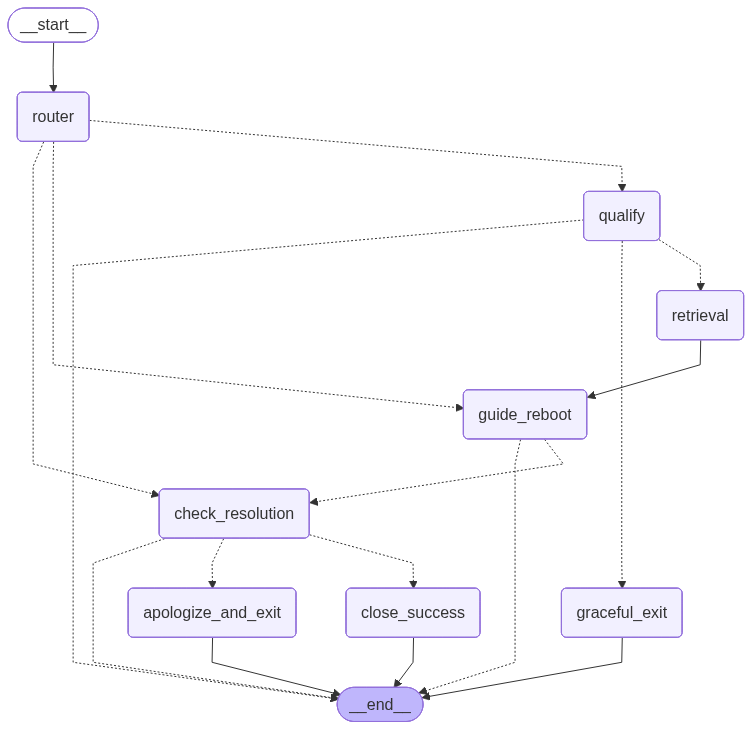

In [12]:
# Visualize graph structure
from IPython.display import Image


try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization not available: {e}")

## 4. RAG Component - Retrieval & Context

In [ ]:
# Test RAG retrieval with different queries
test_queries = [
    "router reboot steps power cord disconnect",
    "how to restart linksys router",
    "reset EA6350",
    "factory reset"
]

for query in test_queries:
    results = retrieve(vectorstore, query)
    print(f"\nQuery: '{query}'")
    print(f"Results found: {len(results)}")
    if results:
        print(f"Top result: {results[0].page_content[:150]}...")

In [ ]:
# Get the RAG context that will be used in guide_reboot node
rag_context = None
results = retrieve(vectorstore, "router reboot steps power cord disconnect")
if results:
    rag_context = results[0].page_content
    print(f"RAG Context (for guide_reboot):")
    print(f"Length: {len(rag_context)} chars")
    print(f"\nContent:\n{rag_context}")
else:
    print("No RAG context found!")

## 5. State Definition

In [ ]:
# Inspect ConversationState structure


print("ConversationState schema:")
print(ConversationState.model_json_schema())

# Print field descriptions
print("\nFields:")
for field_name, field_info in ConversationState.model_fields.items():
    print(f"  {field_name}: {field_info.annotation}")

In [ ]:
# Create test state instances
initial_state = ConversationState(
    messages=[HumanMessage(content="My WiFi is dropping frequently.")]
)
print("Initial state:")
print(initial_state)

# State with conversation history
conversation_state = ConversationState(
    messages=[
        HumanMessage(content="My WiFi keeps dropping."),
        AIMessage(content="Let me help you fix that."),
        HumanMessage(content="Sure, I'm ready."),
    ],
    reboot_appropriate=True,
    current_step=2,
    rag_context="Step 1: Power off the router..."
)
print("\nConversation state:")
print(conversation_state)

## 6. Node Functions - Test in Isolation

In [ ]:
# All node functions are imported from agents.v1.nodes
# They are live references to the actual implementation
# 
# Nodes available:
# - qualify(state) → {messages, reboot_appropriate?, exit_reason?}
# - graceful_exit(state) → {messages, current_node}
# - guide_reboot(state) → {messages, rag_context, current_node, current_step?}
# - check_resolution(state) → {messages, current_node, issue_resolved?}
# - close_success(state) → {messages, current_node}
# - apologize_and_exit(state) → {messages, current_node}

print("Node functions loaded from agents.v1.nodes")
print("Any changes to nodes.py will be reflected immediately")

In [ ]:
# Test: qualify node
print("=== Testing qualify node ===")
test_state = ConversationState(
    messages=[HumanMessage(content="My WiFi keeps dropping every 10 minutes, it's very annoying.")]
)
print(f"Input state messages: {[m.content[:50] + '...' for m in test_state.messages]}")

result = qualify(test_state)
print(f"\nResult:")
print(f"  reboot_appropriate: {result.get('reboot_appropriate')}")
print(f"  exit_reason: {result.get('exit_reason')}")
print(f"  AI reply: {result['messages'][0].content[:100]}...")

In [ ]:
# Test: guide_reboot node (uses RAG)
print("=== Testing guide_reboot node ===")
test_state = ConversationState(
    messages=[
        HumanMessage(content="My WiFi keeps dropping."),
        AIMessage(content="Let's try rebooting. Do you have access to your router?"),
        HumanMessage(content="Yes, I do."),
    ],
    current_step=0
)

result = guide_reboot(test_state)
print(f"Result:")
print(f"  current_node: {result.get('current_node')}")
print(f"  rag_context retrieved: {result.get('rag_context') is not None}")
print(f"  step_complete: {result.get('step_complete')}")
print(f"  AI message: {result['messages'][0].content[:150]}...")

In [ ]:
# Test: check_resolution node
print("=== Testing check_resolution node ===")
test_state = ConversationState(
    messages=[
        HumanMessage(content="My WiFi was dropping."),
        AIMessage(content="Here's how to reboot..."),
        HumanMessage(content="I did the reboot. Now testing..."),
    ],
    current_step=4
)

result = check_resolution(test_state)
print(f"Result:")
print(f"  current_node: {result.get('current_node')}")
print(f"  issue_resolved: {result.get('issue_resolved')}")
print(f"  AI message: {result['messages'][0].content[:100]}...")

In [ ]:
# Test: close_success node
print("=== Testing close_success node ===")
test_state = ConversationState(
    messages=[
        HumanMessage(content="My WiFi was dropping."),
        AIMessage(content="Try rebooting."),
        HumanMessage(content="That fixed it!"),
    ],
    issue_resolved=True
)

result = close_success(test_state)
print(f"Result:")
print(f"  current_node: {result.get('current_node')}")
print(f"  AI message: {result['messages'][0].content}")

In [ ]:
# Test: graceful_exit node
print("=== Testing graceful_exit node ===")
test_state = ConversationState(
    messages=[HumanMessage(content="I don't have a Linksys router.")],
    reboot_appropriate=False,
    exit_reason="Router type mismatch"
)

result = graceful_exit(test_state)
print(f"Result:")
print(f"  current_node: {result.get('current_node')}")
print(f"  AI message: {result['messages'][0].content}")

## 7. Routing Functions - Test Logic

In [ ]:
# All routing functions are imported from agents.v1.nodes
# They are live references to the actual implementation
# 
# Routing functions available:
# - route_after_qualify(state) → "qualify" | "guide_reboot" | "graceful_exit"
# - route_after_guide(state) → "guide_reboot" | "check_resolution"
# - route_after_check(state) → "check_resolution" | "close_success" | "apologize_and_exit"

print("Routing functions loaded from agents.v1.nodes")
print("Any changes to nodes.py routing logic will be reflected immediately")

In [ ]:
# Test route_after_qualify
print("=== Testing route_after_qualify ===")

test_cases = [
    (ConversationState(), "qualify (reboot_appropriate=None)"),
    (ConversationState(reboot_appropriate=True), "guide_reboot (reboot_appropriate=True)"),
    (ConversationState(reboot_appropriate=False), "graceful_exit (reboot_appropriate=False)"),
]

for state, desc in test_cases:
    route = route_after_qualify(state)
    print(f"{desc} → {route}")

In [ ]:
# Test route_after_guide
print("=== Testing route_after_guide ===")

test_cases = [
    (ConversationState(current_step=0), "guide_reboot (current_step=0)"),
    (ConversationState(current_step=2), "guide_reboot (current_step=2)"),
    (ConversationState(current_step=4), "check_resolution (current_step=4)"),
    (ConversationState(current_step=5), "check_resolution (current_step=5)"),
]

for state, desc in test_cases:
    route = route_after_guide(state)
    print(f"{desc} → {route}")

## 9. End-to-End Testing - Full Workflows

In [ ]:
# Scenario 1: Happy path - WiFi drops, user confirms reboot, issue resolves
print("=== SCENARIO 1: Happy Path (Issue Resolves) ===")

import uuid
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# User message 1: Describe issue
print("\n[User] My WiFi keeps disconnecting every few minutes.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="My WiFi keeps disconnecting every few minutes.")]},
    config=config
)
print(f"[Agent] {state['messages'][-1].content}")

# Check state
current_state = compiled_graph.get_state(config)
print(f"Current node: {current_state.next}")

In [ ]:
# Continue scenario 1: User confirms access
print("\n[User] Yes, I can access my router right now.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="Yes, I can access my router right now.")]},
    config=config
)
print(f"[Agent] {state['messages'][-1].content}")

current_state = compiled_graph.get_state(config)
print(f"Current node: {current_state.next}")

In [ ]:
# Continue scenario 1: User confirms reboot completion
print("\n[User] OK, I've rebooted the router.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="OK, I've rebooted the router.")]},
    config=config
)
print(f"[Agent] {state['messages'][-1].content[:150]}...")

current_state = compiled_graph.get_state(config)
print(f"Current node: {current_state.next}")

In [ ]:
# Continue scenario 1: Issue is resolved
print("\n[User] Yes, it's working fine now!")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="Yes, it's working fine now!")]},
    config=config
)
print(f"[Agent] {state['messages'][-1].content}")

current_state = compiled_graph.get_state(config)
print(f"Current node: {current_state.next}")
print(f"Conversation ended: {current_state.next == () or current_state.next == []}")

In [ ]:
# Scenario 2: Early exit - Not a Linksys router
print("\n\n=== SCENARIO 2: Early Exit (Not Compatible) ===")

thread_id_2 = str(uuid.uuid4())
config_2 = {"configurable": {"thread_id": thread_id_2}}

print("\n[User] I have a TP-Link router that won't connect.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="I have a TP-Link router that won't connect.")]},
    config=config_2
)
print(f"[Agent] {state['messages'][-1].content[:150]}...")

current_state = compiled_graph.get_state(config_2)
print(f"Current node: {current_state.next}")

In [ ]:
# Scenario 3: Multiple qualify loops
print("\n\n=== SCENARIO 3: Multiple Qualify Loops ===")

thread_id_3 = str(uuid.uuid4())
config_3 = {"configurable": {"thread_id": thread_id_3}}

print("\n[User] Sometimes my WiFi doesn't work.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="Sometimes my WiFi doesn't work.")]},
    config=config_3
)
print(f"[Agent] {state['messages'][-1].content[:100]}...")

current_state = compiled_graph.get_state(config_3)
print(f"Current node: {current_state.next}")

In [ ]:
# Continue scenario 3: Provide more details
print("\n[User] It drops about 5 times per day, especially in the evening.")
state = compiled_graph.invoke(
    {"messages": [HumanMessage(content="It drops about 5 times per day, especially in the evening.")]},
    config=config_3
)
print(f"[Agent] {state['messages'][-1].content[:100]}...")

current_state = compiled_graph.get_state(config_3)
print(f"Current node (should qualify or move forward): {current_state.next}")